#Classificação

Até agora analisamos apenas casos de regressão, em que prevemos um valor contínuo como nosso target. Hoje usaremos a Árvore de Decisão e Floresta Randômica que já conhecemos nas aulas passadas para realizar previsões de classificação. Neste caso, buscam-se padrões nos dados de features que permitam classificar saídas em duas ou mais categorias.

Para tanto, ambos os algoritmos separam o nosso dataset de features  de treinamento com "splits". Esses splits são decididos utilizando o conceito de entropia da informação, enquanto que no caso de regressão foi utilizado o conceito de variância.

Entropia pode ser definida como a medida que nos diz o quanto nossos dados estão desorganizados e misturados. Quanto maior a entropia, menor o ganho de informação e vice-versa. Nossos dados ficam menos entrópicos conforme dividimos os dados em conjuntos capazes de representar apenas uma classe do nosso modelo.

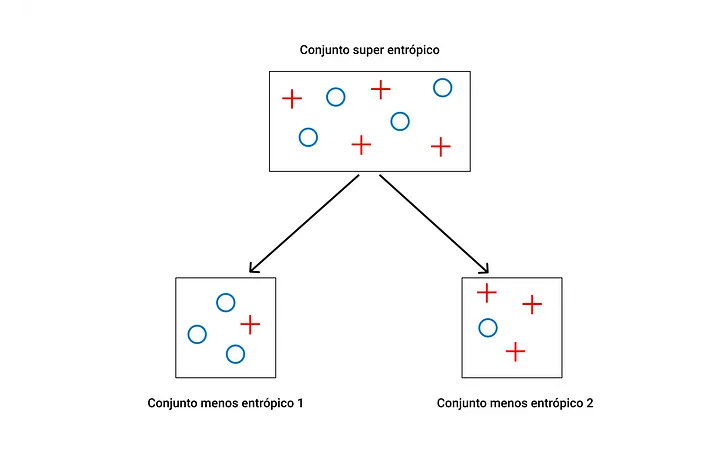

Fonte: [Medium](https://medium.com/data-hackers/como-funciona-uma-%C3%A1rvore-de-decis%C3%A3o-be3eba5918a1)

De toda forma, o objetivo é maximizar o ganho de informação com cada split, como foi o caso de regressões com árvore de decisão e floresta randômica. No caso da floresta randômica, o que temos é um conjunto de N árvores de decisão. Para cada árvore, é obtido um sub dataset de X de treino, contendo 70% do dataset original, de forma randômica. Cria-se então um conjunto de N árvores de decisão diferentes, cada uma com a sua previsão para classificação. a resposta final do algoritmo é dada pela maioria.

#Exemplo de código para Árvore de Decisão

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#from matplotlib.colors import ListedColormap
import pandas as pd
import seaborn as sns

#from sklearn import tree

#from sklearn.impute import SimpleImputer
#from sklearn.compose import ColumnTransformer
#from sklearn.preprocessing import OneHotEncoder
#from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#from sklearn.linear_model import LinearRegression
#from sklearn.tree import DecisionTreeRegressor
#from sklearn.ensemble import RandomForestRegressor

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#from sklearn.model_selection import cross_val_score
#from sklearn.model_selection import GridSearchCV

#from sklearn.metrics import r2_score
#from sklearn.metrics import mean_absolute_error

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [ ]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
print(titanic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [ ]:
dataset = titanic.dropna(axis=0) #retira as linhas com NaN

In [ ]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
Index: 182 entries, 1 to 889
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     182 non-null    int64   
 1   pclass       182 non-null    int64   
 2   sex          182 non-null    object  
 3   age          182 non-null    float64 
 4   sibsp        182 non-null    int64   
 5   parch        182 non-null    int64   
 6   fare         182 non-null    float64 
 7   embarked     182 non-null    object  
 8   class        182 non-null    category
 9   who          182 non-null    object  
 10  adult_male   182 non-null    bool    
 11  deck         182 non-null    category
 12  embark_town  182 non-null    object  
 13  alive        182 non-null    object  
 14  alone        182 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 18.2+ KB
None


In [ ]:
titanic.drop('deck',  axis=1, inplace=True)

In [ ]:
print(titanic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB
None


In [ ]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [ ]:
dataset2 = titanic.dropna(axis=0) #retira as linhas com NaN

In [ ]:
print(dataset2.info())

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     712 non-null    int64   
 1   pclass       712 non-null    int64   
 2   sex          712 non-null    object  
 3   age          712 non-null    float64 
 4   sibsp        712 non-null    int64   
 5   parch        712 non-null    int64   
 6   fare         712 non-null    float64 
 7   embarked     712 non-null    object  
 8   class        712 non-null    category
 9   who          712 non-null    object  
 10  adult_male   712 non-null    bool    
 11  embark_town  712 non-null    object  
 12  alive        712 non-null    object  
 13  alone        712 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 69.0+ KB
None


In [ ]:
y = dataset2.survived

In [ ]:
y

,survived
0,0
1,1
2,1
3,1
4,0
...,...
885,0
886,0
887,1
889,1


In [ ]:
features = ['pclass', 'age', 'sibsp', 'fare', 'parch']

X = dataset2[features]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
y_pred = classifier.predict(X_test)

##Acurácia

Para entender como o algoritmo se comporta e avaliar o resultado, ao invés de avaliar o R² ou MAE (ambos advém de contas numéricas), precisamos adotar a avaliação por acurácia.

In [ ]:
from sklearn.metrics import accuracy_score
y_prev = [0, 2, 1, 3, 4]
y_true = [0, 1, 2, 3, 4]


In [ ]:
accuracy_score(y_true, y_prev) #dá a porcentagem em fração


0.6

In [ ]:
accuracy_score(y_true, y_prev, normalize=False) #dá a contagem dos acertos


3.0

In [ ]:
accuracy_score(y_test, y_pred)

0.5944055944055944

In [ ]:
features = ['pclass', 'age', 'sibsp', 'fare','adult_male']

X = dataset2[features].values
y = dataset2.survived

In [ ]:
X

array([[3, 22.0, 1, 7.25, True],
       [1, 38.0, 1, 71.2833, False],
       [3, 26.0, 0, 7.925, False],
       ...,
       [1, 19.0, 0, 30.0, False],
       [1, 26.0, 0, 30.0, True],
       [3, 32.0, 0, 7.75, True]], dtype=object)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X = np.array(ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [-1])], remainder='passthrough').fit_transform(X))
X

array([[0.0, 1.0, 3, 22.0, 1, 7.25],
       [1.0, 0.0, 1, 38.0, 1, 71.2833],
       [1.0, 0.0, 3, 26.0, 0, 7.925],
       ...,
       [1.0, 0.0, 1, 19.0, 0, 30.0],
       [0.0, 1.0, 1, 26.0, 0, 30.0],
       [0.0, 1.0, 3, 32.0, 0, 7.75]], dtype=object)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
classifier2 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier2.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
y_pred = classifier2.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.8111888111888111

#Exemplo de Código com Floresta Randômica

In [ ]:
from sklearn.ensemble import RandomForestClassifier
classifier_rf = RandomForestClassifier(max_depth= 5, n_estimators = 15, random_state = 0)
classifier_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=15, random_state=0)

In [ ]:
y_pred_rf = classifier_rf.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_rf)

0.8321678321678322

##Matriz de confusão

Matriz que mostra visualmente a acurácia das previsões.

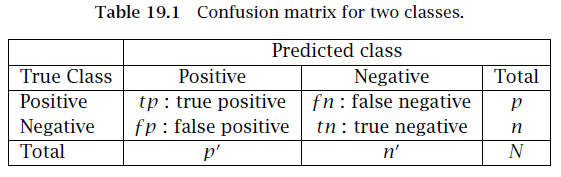

Introduction to Machine Learning - 2nd Edition - Ethem Alpaydın

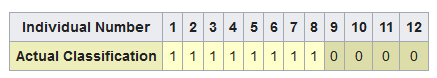

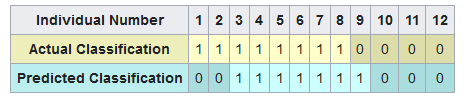

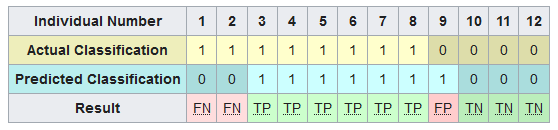

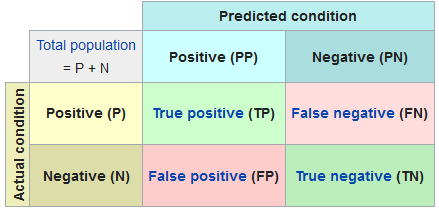

https://en.wikipedia.org/wiki/Confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)
accuracy_score(y_test, y_pred_rf)

[[74  8]
 [16 45]]


0.8321678321678322

In [ ]:
confusion_matrix(y_test, y_pred_rf)

array([[74,  8],
       [16, 45]])

In [1]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();

NameError: name 'ConfusionMatrixDisplay' is not defined

In [ ]:
features = ['pclass', 'fare','adult_male','alone']

X = dataset2[features].values
y = dataset2.survived

In [ ]:
X

array([[3, 7.25, True, False],
       [1, 71.2833, False, False],
       [3, 7.925, False, True],
       ...,
       [1, 30.0, False, True],
       [1, 30.0, True, True],
       [3, 7.75, True, True]], dtype=object)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X = np.array(ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [-1])], remainder='passthrough').fit_transform(X))
X

array([[1.0, 0.0, 3, 7.25, True],
       [1.0, 0.0, 1, 71.2833, False],
       [0.0, 1.0, 3, 7.925, False],
       ...,
       [0.0, 1.0, 1, 30.0, False],
       [0.0, 1.0, 1, 30.0, True],
       [0.0, 1.0, 3, 7.75, True]], dtype=object)

In [ ]:
X = np.array(ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [-1])], remainder='passthrough').fit_transform(X))
X

array([[0.0, 1.0, 1.0, 0.0, 3, 7.25],
       [1.0, 0.0, 1.0, 0.0, 1, 71.2833],
       [1.0, 0.0, 0.0, 1.0, 3, 7.925],
       ...,
       [1.0, 0.0, 0.0, 1.0, 1, 30.0],
       [0.0, 1.0, 0.0, 1.0, 1, 30.0],
       [0.0, 1.0, 0.0, 1.0, 3, 7.75]], dtype=object)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
classifier_rf2 = RandomForestClassifier(max_depth= 5, n_estimators = 15, random_state = 0)
classifier_rf2.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=15, random_state=0)

In [ ]:
y_pred_rf2 = classifier_rf2.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_rf2)

0.8111888111888111

In [ ]:
classifier_rf2.feature_importances_

array([0.26936278, 0.15923608, 0.00944125, 0.01106311, 0.24483198,
       0.3060648 ])